#Which ML Method was Applied and How?
In this case, the flow is very straightforward since my aim is to extract a proper model for the universities in Türkiye classified (labeled) as low, medium, or high. In order to determine the categorical and ordinal target value for each university, I considered each region as distinct attributes which stand for seven different variables to pinpoint a university. Therefore, I did splitting with respect to the percentages belonging to people coming from each region to the corresponding university. I constructed two separate decision trees accordingly by both applying gini-index and entropy while computing the infformation gain. After hyperparameter tuning, I awared that the confusion matrix gives the best accuracy result when depth of the tree is 4 for gini index method, and 3 for entropy method respectively in terms of balance between overfitting and underfitting. Another impoetant notice is that for sure, I first aapplied the model on training data to find the best model by changing hyperparameters and test on test data.



#Why This Model is Appropriate on This Dataset?
Since this part of the project contains qualification of universities according to the regions that students came from, each university can be uniquely represented by the list of percentages from different regions. Hence, by some conditions of threshold values, I can determine which qualification class a university belongs to; which indicates that decision tree is applicable on this dataset.


----- Training Using Gini -----
Predicted Values:
 ['High' 'Medium' 'High' 'High' 'High' 'Medium' 'Medium' 'Low' 'Medium'
 'High' 'Medium' 'Medium' 'Medium' 'High' 'High' 'High' 'Medium' 'Medium'
 'Low' 'Medium' 'Medium' 'High' 'High' 'High' 'Medium' 'Medium' 'High'
 'Medium']

Confusion Matrix:
 [[3 0 4]
 [0 2 1]
 [9 0 9]]

Accuracy: 50.0

Classification Report:
               precision    recall  f1-score   support

        High       0.25      0.43      0.32         7
         Low       1.00      0.67      0.80         3
      Medium       0.64      0.50      0.56        18

    accuracy                           0.50        28
   macro avg       0.63      0.53      0.56        28
weighted avg       0.58      0.50      0.53        28



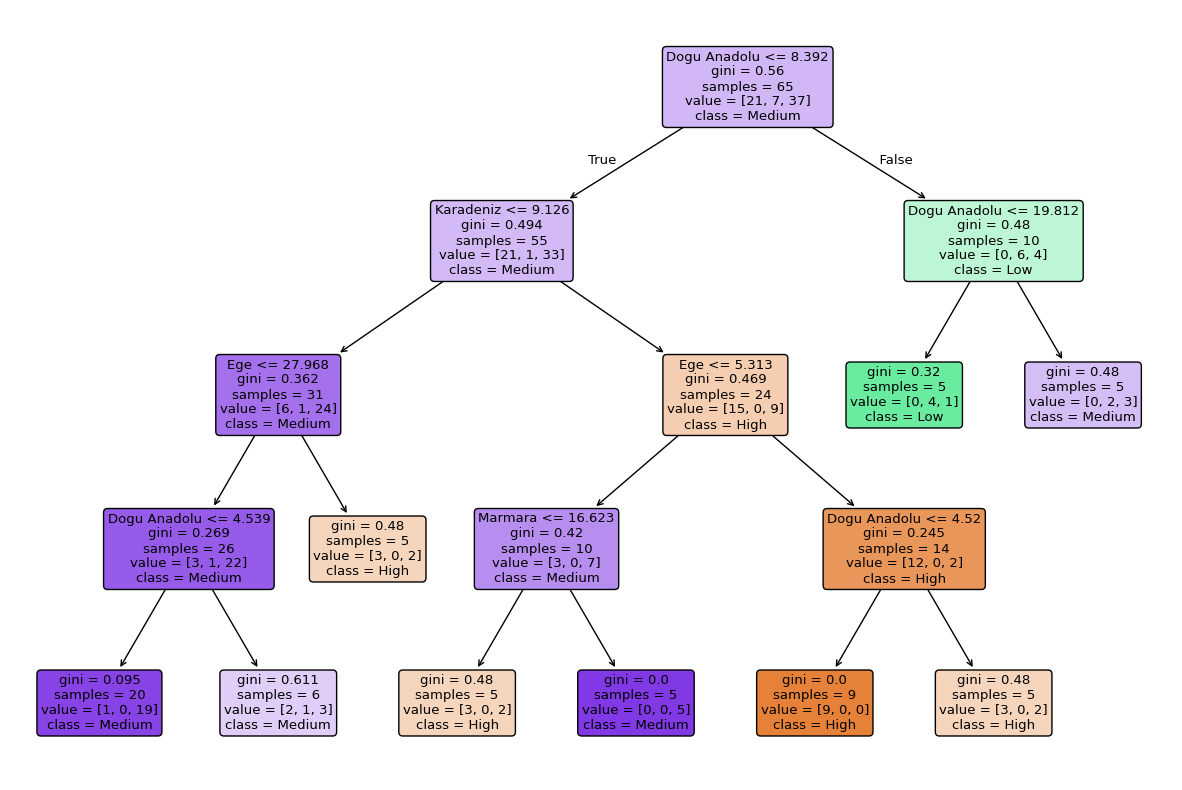


----- Training Using Entropy -----
Predicted Values:
 ['Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Low'
 'Medium' 'High' 'Low' 'High' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium' 'Medium' 'High' 'High' 'Medium' 'Medium' 'High' 'Low'
 'High' 'Medium']

Confusion Matrix:
 [[ 3  1  3]
 [ 0  1  2]
 [ 3  1 14]]

Accuracy: 64.28571428571429

Classification Report:
               precision    recall  f1-score   support

        High       0.50      0.43      0.46         7
         Low       0.33      0.33      0.33         3
      Medium       0.74      0.78      0.76        18

    accuracy                           0.64        28
   macro avg       0.52      0.51      0.52        28
weighted avg       0.63      0.64      0.64        28



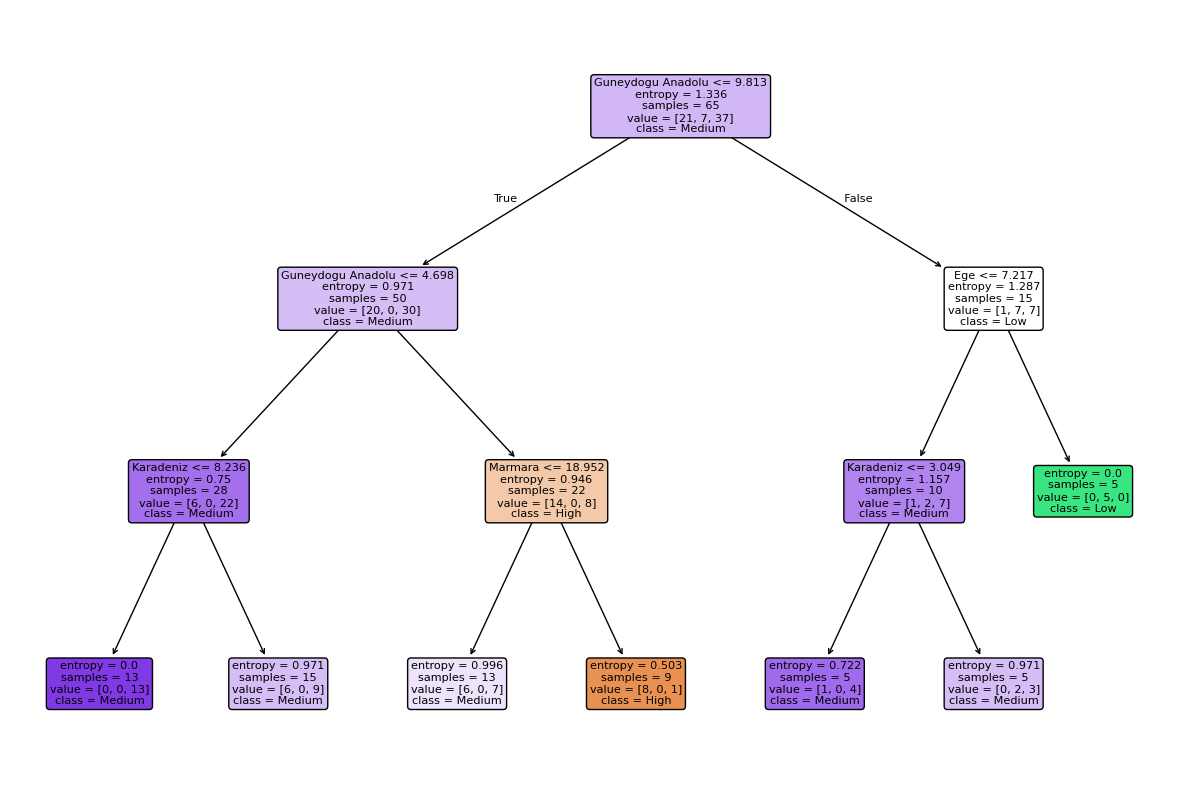

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# read data
df2023 = pd.read_csv("University_by_ranking_2023.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")
df2024 = pd.read_csv("University_by_ranking_2024.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")
df2025 = pd.read_csv("University_by_ranking_2025.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")

dictGeneral = {}
dictGeneral["Ranking"] = []

#computing the ranking of universities for three years scores in each university into a new dictionary by combining 3 dataframes
for i in range(len(df2023)):
  score2023 = (float(df2023.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2023.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  score2024 = (float(df2024.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2024.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  score2025 = (float(df2025.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2025.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  averageScore = (score2023 + score2024 + score2025)/3
  if averageScore < 350:
    dictGeneral["Ranking"].append("Low")
  elif averageScore < 450:
    dictGeneral["Ranking"].append("Medium")
  else:
    dictGeneral["Ranking"].append("High")

#constructing a new table combining number of students coming to the university from regions with the score of the university in each line
dfRegion = pd.read_csv("University_by_regions.csv", encoding = "utf-8", encoding_errors = "replace", sep = ",")
dictGeneral["Akdeniz"] = []
dictGeneral["Dogu Anadolu"] = []
dictGeneral["Ege"] = []
dictGeneral["Guneydogu Anadolu"] = []
dictGeneral["Ic Anadolu"] = []
dictGeneral["Karadeniz"] = []
dictGeneral["Marmara"] = []

for i in range(0, len(dfRegion), 3):
  total = 0;
  akdeniz = int(dfRegion.loc[i, "AKDENIZ"]) + int(dfRegion.loc[i+1, "AKDENIZ"]) + int(dfRegion.loc[i+2, "AKDENIZ"])
  total += akdeniz
  doguAnadolu = int(dfRegion.loc[i, "DOGU ANADOLU"]) + int(dfRegion.loc[i+1, "DOGU ANADOLU"]) + int(dfRegion.loc[i+2, "DOGU ANADOLU"])
  total += doguAnadolu
  ege = int(dfRegion.loc[i, "EGE"]) + int(dfRegion.loc[i+1, "EGE"]) + int(dfRegion.loc[i+2, "EGE"])
  total += ege
  guneydoguAnadolu = int(dfRegion.loc[i, "GUNEYDOGU ANADOLU"]) + int(dfRegion.loc[i+1, "GUNEYDOGU ANADOLU"]) + int(dfRegion.loc[i+2, "GUNEYDOGU ANADOLU"])
  total += guneydoguAnadolu
  icAnadolu = int(dfRegion.loc[i, "IC ANADOLU"]) + int(dfRegion.loc[i+1, "IC ANADOLU"]) + int(dfRegion.loc[i+2, "IC ANADOLU"])
  total += icAnadolu
  karadeniz = int(dfRegion.loc[i, "KARADENIZ"]) + int(dfRegion.loc[i+1, "KARADENIZ"]) + int(dfRegion.loc[i+2, "KARADENIZ"])
  total += karadeniz
  marmara = int(dfRegion.loc[i, "MARMARA"]) + int(dfRegion.loc[i+1, "MARMARA"]) + int(dfRegion.loc[i+2, "MARMARA"])
  total += marmara
  dictGeneral["Akdeniz"].append(100*akdeniz/total)
  dictGeneral["Dogu Anadolu"].append(100*doguAnadolu/total)
  dictGeneral["Ege"].append(100*ege/total)
  dictGeneral["Guneydogu Anadolu"].append(100*guneydoguAnadolu/total)
  dictGeneral["Ic Anadolu"].append(100*icAnadolu/total)
  dictGeneral["Karadeniz"].append(100*karadeniz/total)
  dictGeneral["Marmara"].append(100*marmara/total)

data = pd.DataFrame(dictGeneral)

# split dataset
X = data.iloc[:, 1:10].values
Y = data.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

# training using Gini
print("\n----- Training Using Gini -----")
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=4, min_samples_leaf=5)
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)
print("Predicted Values:\n", y_pred_gini)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("\nAccuracy:", accuracy_score(y_test, y_pred_gini) * 100)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gini))

regionNames = ['Akdeniz', 'Dogu Anadolu', 'Ege', 'Guneydogu Anadolu', 'Ic Anadolu', 'Karadeniz', 'Marmara']
universityRanking = ['High', 'Low', 'Medium']

# plotting decision tree trained using Gini
plt.figure(figsize=(15, 10))
plot_tree(clf_gini, filled=True, feature_names=regionNames, class_names=universityRanking, rounded=True)
plt.show()

# training using Entropy
print("\n----- Training Using Entropy -----")
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)
print("Predicted Values:\n", y_pred_entropy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))
print("\nAccuracy:", accuracy_score(y_test, y_pred_entropy) * 100)
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropy))

# plotting decision tree trained using Entropy
plt.figure(figsize=(15, 10))
plot_tree(clf_entropy, filled=True, feature_names=regionNames, class_names=universityRanking, rounded=True)
plt.show()
